In [3]:
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv("powerplant_data.csv")

In [5]:
df.head()


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
# AT => temperature
# V => vaccum
# AP => pressure
# RH => humidity

#PE => produced energy
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop("PE", axis=1)
y=df["PE"]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [11]:
#Split out data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [13]:
df.shape

(9568, 5)

In [16]:
#SCaling our data
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [18]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [26]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)


X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)



In [20]:
type(X_train_scaled)

numpy.ndarray

In [24]:
type(y_train)
y_train.shape

(7654,)

In [28]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
test_dataset=TensorDataset(X_test_tensor, y_test_tensor)

In [29]:
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

In [44]:
### Deep Learning
##Definig our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model= nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            #2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            #output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [45]:
import torch.optim as optim
model=ANN()

#loss, optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [51]:
#Training our ANN

train_losses=[]
val_losses=[]

best_val_loss=float("inf")

epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        #xb = feature of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs=model(xb)# forward prop....predicted outputs for this batch
        loss=crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.... compute gradients
        optimizer.step() #paramaters are updated

        running_loss +=loss.item() #loss is a tensor =>py float

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    #Validation

    model.eval()
    running_val_loss=0.0

    with torch.no_grad(): #no gradients compute
        for xb, yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs, yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch{epoch+1}/{epoch}==>training loss={epoch_train_loss} & val loss={epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch1/0==>training loss=20.70157505671183 & val loss=19.152435302734375
epoch2/1==>training loss=20.631081171830495 & val loss=19.243989944458008
epoch3/2==>training loss=20.935874942938486 & val loss=19.05254364013672
epoch4/3==>training loss=20.766897439956665 & val loss=18.871919631958008
epoch5/4==>training loss=20.649293994903566 & val loss=19.002260208129883
epoch6/5==>training loss=20.964798498153687 & val loss=19.00979995727539
epoch7/6==>training loss=20.615125942230225 & val loss=18.912187576293945
epoch8/7==>training loss=20.712704495588937 & val loss=18.739809036254883
epoch9/8==>training loss=20.696998695532482 & val loss=20.188228607177734
epoch10/9==>training loss=20.81315424044927 & val loss=18.98550796508789
epoch11/10==>training loss=20.723533940315246 & val loss=18.704265594482422
epoch12/11==>training loss=20.643237755695978 & val loss=18.773542404174805
epoch13/12==>training loss=20.60948688983917 & val loss=19.03575325012207
epoch14/13==>training loss=20.66024750

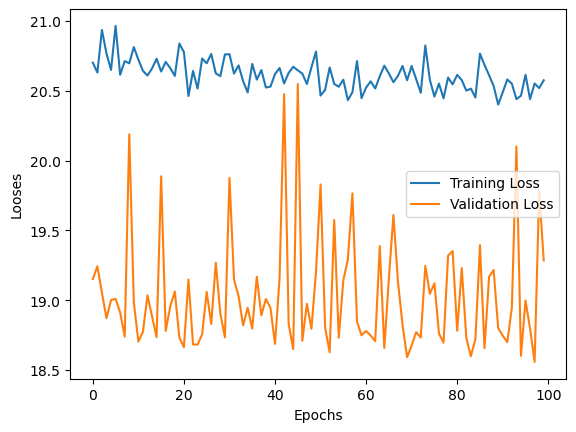

In [55]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss": val_losses
})



plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Looses")
plt.legend()

In [53]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [57]:
#Evaluation of our Model

model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)
    
    train_mse_loss=crietrion(train_preds, y_train_tensor)
    test_mse_loss=crietrion(test_preds, y_test_tensor)

print("Trainign MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Trainign MSE: 20.27243423461914
Testing MSE: 18.562917709350586


In [60]:
from sklearn.metrics import r2_score

print("r^2 score=", r2_score(y_test, test_preds))

r^2 score= 0.9351273869021859


In [62]:
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted values"])
actual_df=pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted values,Actual Values
0,435.021454,433.27
1,436.828644,438.16
2,461.076263,458.42
3,476.234650,480.82
4,434.869141,441.41
...,...,...
1909,451.362793,456.70
1910,431.435822,438.04
1911,467.545258,467.80
1912,430.861023,437.14


In [64]:
# Save the structure and the weights together
torch.save(model, "complete_architecture.pt")

